# SpecML — Patch Reconstruction

Reconstruct full spectra from your trained **SpecML** checkpoint, under **two
protocols on the same frozen model**:

- **Section A · Full-visible** — every token is visible; a single forward pass
  reconstructs all patches. This is the regime `val_loss` reports, but it is an
  *untrained* regime (the model never sees fully-unmasked inputs at train time),
  so reconstructions can look deceptively flat near emission peaks.
- **Section B · Masked (MAE-consistent)** — for each token a leak-free block of
  `BLOCK_K` tokens is masked and predicted from context. This matches the
  training objective and is the **trustworthy** readout (costs N forward passes).

Data: PRISM spectra from the Tokeniser FITS pipeline; per-object redshift / grade
come from the emission-line CSV catalogue, aligned to the spectra. Everything is
in the model’s normalised (arcsinh + per-spectrum z-score) space.

## Config

In [1]:
import sys, math, torch, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '.')

from astropy.table import Table
from SpecML import load_specml

# Importing Tokeniser runs its top-level pipeline: it downloads the PRISM spectra
# FITS, arcsinh-compresses + z-score normalises the flux, and builds the global
# X / V / P tensors. We re-use its normalised flux (f_norm), per-pixel DQ mask
# (dq), wavelength grid (w) and the TWO spectrum-level filters it applied to f,
# then re-tokenise below with whatever patch_size / overlap the checkpoint was
# actually trained with (read from the .pt's embedded _config).
from Tokeniser import (
    f_norm, dq, w,
    valid_spectrum, valid_spectra,   # the two spectra-level filters applied to f
    tokenize,
)
# NB: Training.py is the training entry point (its training loop is guarded by
# __main__), so we do NOT import it here.

CKPT   = 'SpecML.pt'                                  # your trained checkpoint
CSV    = 'dja_msaexp_emission_lines_v4.5.csv.gz'     # emission-line catalogue (metadata)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Drop EDGE_TRIM positions from each end of the sequence in all analysis plots.
# Edge tokens have low overlap count and noisier reconstruction. Scale to the
# sequence length: for P=4/S=2 the sequence is long (~233 tokens), so 2 is fine.
EDGE_TRIM = 2

# BLOCK_K (consecutive tokens masked around each target in Section B) is derived
# automatically from the checkpoint geometry in the model cell below.


## Load frozen model (architecture read from the checkpoint `_config`)

In [2]:
model, cfg = load_specml(CKPT, device=DEVICE)
model.eval()

PATCH_SIZE = cfg['patch_size']
OVERLAP    = cfg['overlap']
STEP       = cfg['step']            # patch_size - overlap
D_EMB      = cfg['D_emb']
PATCH_DIM  = cfg['patch_dim']       # patch_size + 2  (mean, std, then P flux values)

# Leak-free block size for the masked readout (Section B). To fully hide token t,
# you must also zero every token that shares a pixel with it: (P-1)//S each side.
#   S == P (no overlap)  -> BLOCK_K = 1   (leave-one-out)
#   P=4, S=2 (overlap 2) -> BLOCK_K = 3
BLOCK_K = 2 * ((PATCH_SIZE - 1) // STEP) + 1

print('checkpoint config :', cfg)
print(f'patch_size={PATCH_SIZE}  overlap={OVERLAP}  step={STEP}  D_emb={D_EMB}  patch_dim={PATCH_DIM}')
print(f'leak-free BLOCK_K = {BLOCK_K}   (stride {STEP}, patch {PATCH_SIZE})')


checkpoint config : {'patch_dim': 6, 'patch_size': 4, 'overlap': 2, 'step': 2, 'D_emb': 384, 'n_heads': 8, 'n_layers': 8, 'ffn_dim': 1536}
patch_size=4  overlap=2  step=2  D_emb=384  patch_dim=6
leak-free BLOCK_K = 3   (stride 2, patch 4)


## Tokenise + align catalogue + build the reconstruction sample

In [3]:
# ── Tokenise with the CHECKPOINT geometry (may differ from Tokeniser's globals).
X, V, P_enc = tokenize(f_norm, dq, w, PATCH_SIZE, OVERLAP, D_EMB)
print(f'tokens : X {X.shape}  V {V.shape}  P_enc {P_enc.shape}')

# ── Catalogue: per-object metadata (redshift, grade, grating), aligned to f.
catalog = Table.read(CSV, format='ascii')
catalog = catalog[catalog['grating'] == 'PRISM']                 # PRISM only

# Re-apply the SAME two spectrum filters the Tokeniser applied to the flux, in the
# same order, so catalogue rows line up 1:1 with X / f_norm rows. This assumes the
# PRISM-filtered catalogue is in the same order as the FITS spectra columns.
assert len(catalog) == valid_spectrum.shape[0], (
    f'catalogue PRISM rows ({len(catalog)}) != FITS spectra '
    f'({valid_spectrum.shape[0]}). The PRISM catalogue order must match the '
    f'prism_spectra FITS columns.')
catalog = catalog[valid_spectrum][valid_spectra]                 # -> aligns with f / X
assert len(catalog) == X.shape[0], (
    f'aligned catalogue ({len(catalog)}) != tokenised spectra ({X.shape[0]})')

def _col(name, fill=0):
    c = catalog[name]
    return np.asarray(c.filled(fill)) if hasattr(c, 'filled') else np.asarray(c)

z_best = _col('z_best').astype(np.float64)
grade  = _col('grade')

# ── Sample to reconstruct: PRISM + grade 3 + z >= 0  (matches your z_g3 snippet).
# Broaden this if you like, but keep z >= 0 so rest-frame plots stay well-defined.
SELECT = (grade == 3) & (z_best >= 0)
print(f'selection : grade==3 & z>=0  ->  {int(SELECT.sum())} / {len(SELECT)} spectra')

sel_idx   = np.where(SELECT)[0]
X_sel     = X[sel_idx]
V_sel     = V[sel_idx]
fnorm_sel = f_norm[sel_idx].astype(np.float32)
dq_sel    = np.asarray(dq)[sel_idx]
z_sel     = z_best[sel_idx].astype(np.float32)


class SpecDataset:
    """Tokenised spectra + per-pixel originals + redshift for one population."""
    def __init__(self, X, V, flux_norm, dq, w, z_best, sn50=None):
        self.X         = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.V         = torch.from_numpy(np.ascontiguousarray(V)).bool()
        self.flux_norm = torch.from_numpy(np.ascontiguousarray(flux_norm)).float()
        self.dq        = torch.from_numpy(np.ascontiguousarray(dq)).bool()
        self.w         = torch.from_numpy(np.asarray(w, dtype=np.float32))
        self.z_best    = np.asarray(z_best, dtype=np.float64)
        self.sn50      = (np.asarray(sn50, dtype=np.float64)
                          if sn50 is not None else np.full(len(self.z_best), np.nan))
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return dict(X=self.X[i], V=self.V[i], flux_norm=self.flux_norm[i],
                    dq=self.dq[i], redshift=float(self.z_best[i]))


def make_loader(ds, batch_size=256, indices=None):
    idx   = np.arange(len(ds)) if indices is None else np.asarray(indices)
    w_pix = ds.w
    def loader():
        for s in range(0, len(idx), batch_size):
            bn = idx[s:s + batch_size]
            bt = torch.as_tensor(bn, dtype=torch.long)
            yield dict(
                X         = ds.X[bt],
                V         = ds.V[bt],
                flux_norm = ds.flux_norm[bt],
                dq        = ds.dq[bt],
                wave      = w_pix.unsqueeze(0).expand(len(bn), -1).clone(),
                redshift  = torch.as_tensor(ds.z_best[bn], dtype=torch.float32),
            )
    return loader


ds         = SpecDataset(X_sel, V_sel, fnorm_sel, dq_sel, w, z_sel)
val_loader = make_loader(ds, batch_size=256)
P_enc_t    = torch.from_numpy(np.ascontiguousarray(P_enc)).float()   # (T, D_emb) shared

batch = next(val_loader())
print(f"first batch X : {tuple(batch['X'].shape)}   device : {DEVICE}")


tokens : X (42195, 233, 6)  V (42195, 233)  P_enc (233, 384)
selection : grade==3 & z>=0  ->  21492 / 42195 spectra
first batch X : (256, 233, 6)   device : cpu


## Helpers — reconstruction & analysis

A single `reconstruct(model, batch, masked=, block_k=)` covers both protocols and
returns an identical dict, so every analysis function below works unchanged for
Section A and Section B. The analyses take a `recon_fn` closure
(`lambda b: reconstruct(model, b, masked=...)`).

In [4]:
@torch.no_grad()
def reconstruct(model, batch, masked=False, block_k=None):
    """SpecML patch reconstruction, overlap-averaged into a pixel spectrum.

    masked=False : single forward pass, all tokens visible (the val_loss regime;
                   an *untrained* regime, since the model never sees fully-unmasked
                   inputs during training -> peaks can look flat).
    masked=True  : for each token t, zero a leak-free block of `block_k` tokens
                   centred on t (whole patch vectors zeroed, exactly as the training
                   mask does), forward once, and keep that pass's prediction for t.
                   This matches the MAE training objective. Cost: T forward passes.

    SpecML patches carry [mean, std, P flux values]; we reconstruct all P+2 channels
    but only the trailing P flux channels are overlap-averaged into the pixel
    spectrum. Everything is in the model's normalised (arcsinh + per-spectrum
    z-score) space -- the space the model is trained and evaluated in. Physical-flux
    inversion is non-linear (arcsinh) and intentionally not wired in here, so
    `recon_flux` == `recon_norm` and mean/std are identity.
    """
    if block_k is None:
        block_k = BLOCK_K

    Xb    = batch['X'].to(DEVICE)          # (B, T, P+2)
    Vb    = batch['V'].to(DEVICE)          # (B, T) bool
    Pe    = P_enc_t.to(DEVICE)             # (T, D_emb) shared positional encoding
    fnorm = batch['flux_norm']             # (B, L) cpu  -- per-pixel original (norm space)
    dqpix = batch['dq']                    # (B, L) cpu bool -- per-pixel DQ validity
    wave  = batch['wave']                  # (B, L) cpu
    z     = batch['redshift']              # (B,) cpu

    B, T, Pp2 = Xb.shape
    P      = Pp2 - 2
    S      = STEP
    L_used = (T - 1) * S + P

    target_pat = Xb[:, :, 2:]              # (B, T, P) f_norm target patches

    if not masked:
        recon_pat = model(Xb, Vb, Pe)[:, :, 2:]                 # (B, T, P)
    else:
        recon_pat = torch.zeros(B, T, P, device=DEVICE)
        half = (block_k - 1) // 2
        for t in range(T):
            lo, hi = max(0, t - half), min(T, t + half + 1)
            Xm = Xb.clone()
            Xm[:, lo:hi, :] = 0.0                               # zero whole patch vectors
            recon_pat[:, t, :] = model(Xm, Vb, Pe)[:, t, 2:]

    # ── Overlap-average FULLY-VALID tokens (V) into a pixel spectrum. In SpecML, V
    # is already True iff every pixel in the patch is DQ-valid, so a kept token only
    # covers valid pixels -> recon_mask is automatically a subset of the per-pixel
    # DQ mask. Patch t covers pixels [t*S, t*S+P).
    token_full_valid = Vb                                       # (B, T)
    recon_pix = torch.zeros(B, L_used, device=DEVICE)
    count     = torch.zeros(B, L_used, device=DEVICE)
    for t in range(T):
        s  = t * S
        wt = token_full_valid[:, t].to(recon_pat.dtype).unsqueeze(-1)   # (B, 1)
        recon_pix[:, s:s + P] += recon_pat[:, t, :] * wt
        count[:, s:s + P]     += wt
    recon_mask = count > 0                                      # (B, L_used) subset of DQ
    recon_pix  = recon_pix / count.clamp(min=1)

    target_pix = fnorm[:, :L_used]                             # (B, L_used) original (norm)

    return dict(
        flux       = target_pix.cpu(),                         # norm space (no physical inversion)
        wave       = wave[:, :L_used].cpu(),
        vmask      = dqpix[:, :L_used].cpu(),
        recon_mask = recon_mask.cpu(),                         # >=1 valid token covers pixel
        flux_norm  = target_pix.cpu(),
        recon_norm = recon_pix.cpu(),
        recon_flux = recon_pix.cpu(),                          # == recon_norm (norm space)
        patches    = target_pat.cpu(),                         # (B, T, P) target
        recon_pat  = recon_pat.cpu(),                          # (B, T, P) predicted
        token_vmask= Vb.cpu(),                                 # (B, T)
        count      = count.cpu(),                              # (B, L_used)
        mean       = torch.zeros(B, 1),                        # identity inverse (norm space)
        std        = torch.ones(B, 1),
        redshift   = z.cpu() if isinstance(z, torch.Tensor) else torch.as_tensor(z),
        N=T, P=P, S=S, L_used=L_used,
    )


In [5]:
# Rest-frame emission lines (µm), sorted by wavelength.
EMISSION_LINES = {
    r'Ly$\alpha$':          0.1216,
    '[OII]':                0.3727,
    r'H$\beta$':            0.4861,
    '[OIII]':               0.5007,
    r'H$\alpha$':           0.6563,
    '[SII]':                0.6724,
    r'Pa$\zeta$':           0.9229,
    r'Pa$\epsilon$+[SIII]': 0.9539,
    r'Pa$\delta$':          1.0049,
    r'Pa$\gamma$':          1.0938,
}

def _annotate_elines(ax, w_min, w_max, fontsize=8):
    # Draw rest-frame emission-line markers with staggered labels.
    visible = [(name, wl) for name, wl in EMISSION_LINES.items()
               if w_min <= wl <= w_max]
    if not visible:
        return
    visible.sort(key=lambda x: x[1])
    ylo, yhi = ax.get_ylim()
    yspan    = yhi - ylo
    y_levels = [yhi - 0.04 * yspan, yhi - 0.20 * yspan]
    for i, (name, wl) in enumerate(visible):
        ax.axvline(wl, color='#999999', ls='--', lw=1.0, alpha=0.8)
        ax.text(wl, y_levels[i % 2], name, ha='center', va='top',
                fontsize=fontsize, color='#333333', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.75, pad=1.5, edgecolor='none'))


def recon_summary(R, tag=""):
    # Per-token / per-sample MSE stats + overlap-count diagnostic.
    tok_mse = ((R["recon_pat"] - R["patches"]) ** 2).mean(-1)          # (B, N)
    pmask   = R["recon_mask"].float()                     # fully-valid-token reconstruction (subset of vmask)
    pix_err = ((R["recon_norm"] - R["flux_norm"]) ** 2) * pmask
    pix_mse = pix_err.sum(-1) / pmask.sum(-1).clamp(min=1)

    print(f"[{tag}]  Pixel MSE (norm)  mean={pix_mse.mean():.4f}  std={pix_mse.std():.4f}  median={pix_mse.median():.4f}")
    print(f"[{tag}]  Token MSE (norm)  mean={tok_mse[R['token_vmask']].mean():.4f}  std={tok_mse[R['token_vmask']].std():.4f}")
    print(f"[{tag}]  Overlap count     min={R['count'].min():.0f}  max={R['count'].max():.0f}"
          f"  (P={R['P']}, S={R['S']} -> expect max {R['P']//R['S']})")

    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    axes[0].hist(pix_mse.numpy(), bins=40, edgecolor="none")
    axes[0].set(title="Per-sample pixel MSE (norm)", xlabel="MSE", ylabel="count")
    axes[1].hist(tok_mse[R["token_vmask"]].numpy(), bins=40, edgecolor="none")
    axes[1].set(title="Per-token MSE (norm)", xlabel="MSE", ylabel="count")
    axes[1].set_yscale("log")
    axes[2].plot(R["count"][0].numpy(), lw=1.5)
    axes[2].set(title="Pixel overlap count -- sample 0", xlabel="pixel index",
                ylabel="n patches covering pixel")
    fig.suptitle(f"Reconstruction stats -- {tag}", fontweight="bold")
    plt.tight_layout(); plt.show()
    return tok_mse


def gallery(R, tag="", n_gallery=128, space='normalized', max_cols=4,
            panel_w=3.5, panel_h=2.5, seed=0):
    # Grid of original vs reconstructed spectra (rest-frame).
    rng    = np.random.default_rng(seed)
    N_tot  = R["flux"].shape[0]
    n_plot = min(n_gallery, N_tot)
    idxs   = rng.choice(N_tot, size=n_plot, replace=False)
    n_cols = min(max_cols, n_plot)
    n_rows = math.ceil(n_plot / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(panel_w * n_cols, panel_h * n_rows),
                             squeeze=False)
    flat = axes.flatten()
    legend_done = False          # legend goes on the first VISIBLE panel (panel 0 may be masked out)
    for ai, idx in enumerate(idxs):
        ax = flat[ai]
        m  = R["recon_mask"][idx].clone()
        L_used = m.shape[0]
        if EDGE_TRIM > 0:
            m[:EDGE_TRIM] = False
            m[L_used - EDGE_TRIM:] = False
        if m.sum() == 0:
            ax.set_visible(False); continue
        # Observed-frame in; divide by (1+z) to plot rest-frame.
        w  = (R["wave"][idx] / (1.0 + R["redshift"][idx].item()))[m].numpy()
        si = np.argsort(w); w = w[si]
        if space == 'normalized':
            orig  = R["flux_norm"][idx][m].numpy()[si]
            recon = R["recon_norm"][idx][m].numpy()[si]
            ylab  = "Norm. flux"
        else:
            mn, sd = R["mean"][idx].item(), R["std"][idx].item()
            orig  = R["flux"][idx][m].numpy()[si]
            recon = R["recon_norm"][idx][m].numpy()[si] * sd + mn
            ylab  = "Flux (uJy)"
        mse = float(np.mean((orig - recon) ** 2))
        ax.plot(w, orig,  color='steelblue', lw=1.0, alpha=0.85, label='Orig')
        ax.plot(w, recon, color='tomato',    lw=1.0, alpha=0.85, ls='--', label='Recon')
        _annotate_elines(ax, w[0], w[-1], fontsize=6)   # rest-frame emission-line markers
        ax.set_title(f'#{idx}  MSE={mse:.3f}', fontsize=7)
        ax.set_xlabel('λ rest (µm)', fontsize=6)
        ax.set_ylabel(ylab, fontsize=6)
        ax.tick_params(labelsize=5); ax.grid(alpha=0.25)
        if not legend_done:
            ax.legend(fontsize=5, loc='upper right')
            legend_done = True
    for ai in range(n_plot, len(flat)):
        flat[ai].set_visible(False)
    stag = 'Normalized' if space == 'normalized' else 'Physical (uJy)'
    plt.suptitle(f'Patch Reconstruction ({tag}) -- {stag}  '
                 f'[n={n_plot}, P={R["P"]}, S={R["S"]}, edge_trim={EDGE_TRIM}]',
                 fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()


def per_token_bar(R, tok_mse, i=20, tag=""):
    # Per-token reconstruction error for a single sample.
    P, S = R["P"], R["S"]
    w_full = R["wave"][i] / (1.0 + R["redshift"][i].item())
    tok_w  = w_full[:R["L_used"]].unfold(0, P, S).mean(-1).numpy()
    tok_e  = tok_mse[i].numpy()
    tv     = R["token_vmask"][i].clone().numpy()
    N_tok  = len(tv)
    if EDGE_TRIM > 0:
        tv[:EDGE_TRIM] = False
        tv[N_tok - EDGE_TRIM:] = False
    fig, ax = plt.subplots(figsize=(10, 2.5))
    ax.bar(tok_w[tv], tok_e[tv], width=0.012, alpha=0.8, color="steelblue")
    ax.set_xlabel("rest wavelength (μm)")
    ax.set_ylabel("token MSE (norm)")
    ax.set_title(f"Per-token reconstruction error ({tag}) -- sample {i}  "
                 f"(P={P}, S={S}, N={R['N']} tokens, edge_trim={EDGE_TRIM})")
    ax.set_yscale('log')
    plt.tight_layout(); plt.show()

In [6]:
def mse_vs_wavelength(recon_fn, tag="", n_lambda_bins=40, n_mse_bins=60,
                      log_mse_min=-4.0, log_mse_max=1.0, cmap='viridis'):
    # 2D histogram of reconstruction MSE vs rest-frame wavelength (all val).
    all_wave, all_err2 = [], []
    for b in val_loader():
        Rb = recon_fn(b)
        m  = Rb["recon_mask"].clone()
        L_used = m.shape[1]
        if EDGE_TRIM > 0:
            m[:, :EDGE_TRIM] = False
            m[:, L_used - EDGE_TRIM:] = False
        w  = Rb["wave"] / (1.0 + Rb["redshift"].unsqueeze(-1))
        e2 = (Rb["recon_norm"] - Rb["flux_norm"]) ** 2
        all_wave.append(w[m].numpy()); all_err2.append(e2[m].numpy())
    wave_all = np.concatenate(all_wave); err2_all = np.concatenate(all_err2)
    print(f"[{tag}]  Total valid pixels : {len(wave_all):,}  (edge_trim={EDGE_TRIM})")
    print(f"[{tag}]  Mean pixel MSE     : {err2_all.mean():.4f}  +-  {err2_all.std():.4f}")

    valid    = err2_all > 0
    log_err2 = np.log10(err2_all[valid]); wave_v = wave_all[valid]
    log_bins = np.linspace(log_mse_min, log_mse_max, n_mse_bins + 1)
    lam_bins = np.linspace(wave_v.min(), wave_v.max(), n_lambda_bins + 1)
    h, xedge, yedge = np.histogram2d(wave_v, log_err2, bins=[lam_bins, log_bins])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    yticks = np.arange(log_mse_min, log_mse_max + 0.5, 1.0)
    ax = axes[0]
    im = ax.pcolormesh(xedge, yedge, h.T, cmap=cmap)
    fig.colorbar(im, ax=ax, label='pixel count')
    ax.set_yticks(yticks); ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks])
    ax.set_xlabel('rest wavelength (µm)')
    ax.set_ylabel('pixel squared error (norm, log scale)')
    ax.set_title('2D histogram -- log(MSE) vs λ')

    bin_centers = 0.5 * (xedge[:-1] + xedge[1:])
    bin_idx = np.digitize(wave_v, xedge) - 1
    bin_idx = bin_idx.clip(0, n_lambda_bins - 1)
    median_log = np.array([np.median(log_err2[bin_idx == k]) if (bin_idx == k).any() else np.nan
                           for k in range(n_lambda_bins)])
    p84_log = np.array([np.percentile(log_err2[bin_idx == k], 84) if (bin_idx == k).any() else np.nan
                        for k in range(n_lambda_bins)])
    ax = axes[1]
    ax.plot(bin_centers, median_log, color='C0', lw=1.5, label='median')
    ax.fill_between(bin_centers, median_log, p84_log, alpha=0.25, color='C0', label='50–84th pct')
    ax.set_yticks(yticks); ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks])
    ax.set_xlabel('rest wavelength (µm)')
    ax.set_ylabel('pixel squared error (norm, log scale)')
    ax.set_title('Median log(MSE) vs λ'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle(f'{tag} -- reconstruction error vs wavelength  '
                 f'(n={len(wave_v):,} valid pixels, edge_trim={EDGE_TRIM})',
                 fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()


def recon_vs_orig(recon_fn, tag="", max_scatter_pts=8000):
    # Per-sample MSE histogram, orig-vs-recon scatter, residual distribution.
    mse_list, mae_list, orig_pool, recon_pool = [], [], [], []
    for b in val_loader():
        Rb = recon_fn(b)
        m  = Rb["recon_mask"].bool()
        for i in range(Rb["flux_norm"].shape[0]):
            mi = m[i]
            if mi.sum() == 0:
                continue
            o = Rb["flux_norm"][i][mi].numpy()
            r = Rb["recon_norm"][i][mi].numpy()
            mse_list.append(float(np.mean((o - r) ** 2)))
            mae_list.append(float(np.mean(np.abs(o - r))))
            orig_pool.append(o); recon_pool.append(r)
    mse_arr  = np.array(mse_list); mae_arr = np.array(mae_list)
    orig_all = np.concatenate(orig_pool); recon_all = np.concatenate(recon_pool)
    resid    = recon_all - orig_all


    #rng_sc = np.random.default_rng(0)
    #if len(orig_all) > max_scatter_pts:
    #    sel = rng_sc.choice(len(orig_all), max_scatter_pts, replace=False)
    #    o_sc, r_sc = orig_all[sel], recon_all[sel]
    #else:
    o_sc, r_sc = orig_all, recon_all
    r_val = np.corrcoef(o_sc, r_sc)[0, 1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ax = axes[0]
    ax.hist(mse_arr, bins=35, color='steelblue', alpha=0.8, edgecolor='black', lw=0.4)
    ax.axvline(mse_arr.mean(), color='red', ls='--', lw=1.5,
               label=f'mean={mse_arr.mean():.4f}  std={mse_arr.std():.4f}')
    ax.set_xlabel('Per-sample MSE (norm)'); ax.set_ylabel('Count')
    ax.set_title('MSE Distribution'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1]
    # 2D density (log-scaled counts) instead of a scatter: dense cores stay
    # readable when there are millions of pixels. Empty hexes left blank (mincnt=1).
    # Independent, percentile-clipped ranges per axis (x fits Original, y fits
    # Reconstructed) so a handful of extreme pixels don't stretch the view.
    PCT = (0.1, 99.9)
    xlo, xhi = np.percentile(o_sc, PCT)
    ylo, yhi = np.percentile(r_sc, PCT)
    hb = ax.hexbin(o_sc, r_sc, gridsize=90, bins='log', cmap='viridis',
                   extent=(xlo, xhi, ylo, yhi), mincnt=1)
    fig.colorbar(hb, ax=ax, label='log$_{10}$(pixel count)')
    d_lo, d_hi = max(xlo, ylo), min(xhi, yhi)          # 1:1 line over common range
    ax.plot([d_lo, d_hi], [d_lo, d_hi], 'w--', lw=1, label='1:1')
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
    ax.set_xlabel('Original (norm)'); ax.set_ylabel('Reconstructed (norm)')
    ax.set_title(f'2D density  r={r_val:.3f}  (n={len(o_sc):,})')
    ax.legend(fontsize=8, loc='upper left')

    ax = axes[2]
    ax.hist(resid, bins=50, color='mediumseagreen', alpha=0.8, edgecolor='black', lw=0.4)
    ax.axvline(0, color='k', ls='--', lw=1.0)
    ax.axvline(resid.mean(), color='red', ls='-', lw=1.5,
               label=f'mean={resid.mean():.4f}  std={resid.std():.4f}')
    ax.set_xlabel('Residual (Recon − Orig)'); ax.set_ylabel('Count')
    ax.set_title('Residual Distribution'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle(f'{tag} -- Reconstruction Statistics [Normalized]  n={len(mse_arr)}\n'
                 f'MSE={mse_arr.mean():.4f}±{mse_arr.std():.4f}   '
                 f'MAE={mae_arr.mean():.4f}±{mae_arr.std():.4f}',
                 fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

In [7]:
def outlier_analysis(recon_fn, tag="", outlier_nsigma=5.0, n_gallery_out=128):
    # Flag pixels whose residual deviates > nsigma from the global mean, then plot
    # scatter / wavelength distribution / outlier-rate, plus a gallery of the
    # spectra with the most outlier pixels.
    records = []
    for b in val_loader():
        Rb = recon_fn(b)
        m  = Rb["recon_mask"].bool().clone()
        L_used = m.shape[1]
        if EDGE_TRIM > 0:
            m[:, :EDGE_TRIM] = False
            m[:, L_used - EDGE_TRIM:] = False
        w_rest = Rb["wave"] / (1.0 + Rb["redshift"].unsqueeze(-1))
        for i in range(Rb["flux_norm"].shape[0]):
            mi = m[i]
            if mi.sum() == 0:
                continue
            records.append((Rb["flux_norm"][i][mi].numpy(),
                            Rb["recon_norm"][i][mi].numpy(),
                            w_rest[i][mi].numpy()))
    orig_pix  = np.concatenate([x[0] for x in records])
    recon_pix = np.concatenate([x[1] for x in records])
    wave_pix  = np.concatenate([x[2] for x in records])
    resid_pix = recon_pix - orig_pix

    r_mean, r_std = resid_pix.mean(), resid_pix.std()
    is_outlier = np.abs(resid_pix - r_mean) > outlier_nsigma * r_std
    print(f"[{tag}]  Total pixels   : {len(resid_pix):,}  (edge_trim={EDGE_TRIM})")
    print(f"[{tag}]  Outlier pixels : {is_outlier.sum():,}  ({100*is_outlier.mean():.2f}%)"
          f"  threshold = ±{outlier_nsigma}σ  (σ={r_std:.4f})")

    w_min, w_max = wave_pix.min(), wave_pix.max()
    bins_w = np.linspace(w_min, w_max, 60)
    bin_centers = 0.5 * (bins_w[:-1] + bins_w[1:])
    bin_idx_arr = np.digitize(wave_pix, bins_w).clip(1, len(bins_w) - 1) - 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ax = axes[0]
    rng_o   = np.random.default_rng(42)
    sel_in  = rng_o.choice(np.where(~is_outlier)[0], min(5000, (~is_outlier).sum()), replace=False)
    sel_out = rng_o.choice(np.where( is_outlier)[0], min(2000,  is_outlier.sum()),  replace=False)
    ax.scatter(orig_pix[sel_in],  recon_pix[sel_in],  s=2, alpha=0.2, color='purple',
               label='Normal', rasterized=True)
    ax.scatter(orig_pix[sel_out], recon_pix[sel_out], s=8, alpha=0.6, color='tomato',
               label=f'Outlier (>{outlier_nsigma}σ)', rasterized=True, zorder=5)
    lo, hi = min(orig_pix.min(), recon_pix.min()), max(orig_pix.max(), recon_pix.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel('Original (norm)'); ax.set_ylabel('Reconstructed (norm)')
    ax.set_title('Orig vs Recon -- outliers highlighted'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.hist(wave_pix,             bins=bins_w, color='steelblue', alpha=0.5, density=True, label='All pixels')
    ax.hist(wave_pix[is_outlier], bins=bins_w, color='tomato',    alpha=0.75, density=True,
            label=f'Outliers (>{outlier_nsigma}σ)')
    _annotate_elines(ax, w_min, w_max)
    ax.set_xlabel('Rest wavelength (µm)'); ax.set_ylabel('Density')
    ax.set_title('Wavelength: outlier pixels vs all'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[2]
    out_rate = np.array([is_outlier[bin_idx_arr == k].mean() if (bin_idx_arr == k).any() else np.nan
                         for k in range(len(bins_w) - 1)])
    ax.bar(bin_centers, out_rate, width=(bins_w[1] - bins_w[0]) * 0.9, color='tomato', alpha=0.8)
    ax.set_ylim(0, np.nanmax(out_rate) * 1.35)
    _annotate_elines(ax, w_min, w_max)
    ax.set_xlabel('Rest wavelength (µm)'); ax.set_ylabel('Outlier fraction')
    ax.set_title('Outlier rate vs wavelength'); ax.grid(alpha=0.3)

    plt.suptitle(f'{tag} -- Outlier Analysis: {is_outlier.sum():,} outlier pixels  '
                 f'({100*is_outlier.mean():.2f}%)   threshold = ±{outlier_nsigma}σ  '
                 f'(edge_trim={EDGE_TRIM})', fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Gallery of spectra with the most outlier pixels.
    offset, ranked = 0, []
    for o, r, w in records:
        n = len(o)
        omask = is_outlier[offset:offset + n]
        ranked.append((omask.sum(), o, r, w, omask)); offset += n
    ranked.sort(key=lambda x: -x[0])
    n_show = min(n_gallery_out, len(ranked))
    n_cols = 4; n_rows = math.ceil(n_show / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)
    flat = axes.flatten()
    for ai, (n_out, o, r, w, omask) in enumerate(ranked[:n_show]):
        ax = flat[ai]
        si = np.argsort(w); w_s, o_s, r_s = w[si], o[si], r[si]
        ax.plot(w_s, o_s, color='steelblue', lw=1.2, alpha=0.85, label='Orig')
        ax.plot(w_s, r_s, color='tomato',    lw=1.2, alpha=0.85, ls='--', label='Recon')
        if omask.any():
            ax.scatter(w[omask], o[omask], s=40, color='red', zorder=6, label='Outlier px')
        _annotate_elines(ax, w_s[0], w_s[-1])
        ax.set_title(f'n_outlier={n_out}', fontsize=8)
        ax.set_xlabel('λ rest (µm)', fontsize=7); ax.set_ylabel('Norm flux', fontsize=7)
        ax.tick_params(labelsize=6); ax.grid(alpha=0.25)
        if ai == 0:
            ax.legend(fontsize=6, loc='upper right')
    for ai in range(n_show, len(flat)):
        flat[ai].set_visible(False)
    plt.suptitle(f'{tag} -- spectra with most outlier pixels '
                 '(red dots = outlier pixels, gray dashed = emission lines)',
                 fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()


def residual_map(recon_fn, dataset, tag="", outliers_only=False, outlier_nsigma=5.0,
                 z_bins=200, wave_bins=112, batch_size=256,
                 min_sn50=None, min_z=None, max_z=None, cmap=None, metric='mean'):
    """2D map of a reconstruction-residual statistic over (redshift, rest-frame λ).

    Each validation pixel contributes its residual (Recon - Orig, normalised flux)
    at coordinates (object redshift z, REST-frame wavelength λ/(1+z)). Pixels are
    binned on a z x λ_rest grid and reduced per bin by `metric`. Because emission
    lines sit at fixed REST-frame wavelengths, any line-correlated reconstruction
    systematic shows up as a HORIZONTAL stripe; a z- or λ-dependent bias shows up
    as broader vertical/diagonal structure. This is the key diagnostic for whether
    the model mis-reconstructs specific lines or specific spectral regions.

    metric:
        'mean' -> signed mean(Recon-Orig) per bin = bias  (diverging cmap, +/-vmax)
        'mse'  -> mean residual^2 per bin               (sequential cmap, vmin=0)
        'rmse' -> sqrt(MSE) per bin                      (sequential cmap, vmin=0)
    outliers_only: keep only pixels whose residual is > outlier_nsigma sigma from
        the global residual mean, to map WHERE the worst pixels concentrate.
    cmap=None picks a metric-appropriate default (coolwarm / magma); override to force.
    `dataset` is a SpecDataset already built for the desired sample; sorting
    its objects by redshift gives a dense, ordered z axis.

    min_sn50 / min_z / max_z: OPTIONAL extra object-level selection applied on top
        of `dataset` (each defaults to None = no cut). When given they sub-select
        objects by dataset.sn50 / dataset.z_best BEFORE sorting, so you can zoom
        the map onto e.g. high-S/N or a redshift slice without rebuilding the
        dataset:  sn50 >= min_sn50,  z_best > min_z,  z_best <= max_z.
    """
    # ---- Optional object-level sub-selection on top of `dataset` (each None = off).
    sn50_all = np.asarray(dataset.sn50, dtype=np.float64)
    z_all    = np.asarray(dataset.z_best, dtype=np.float64)
    sel = np.ones(len(z_all), dtype=bool)
    if min_sn50 is not None:
        sel &= np.isfinite(sn50_all) & (sn50_all >= min_sn50)
    if min_z is not None:
        sel &= np.isfinite(z_all) & (z_all > min_z)
    if max_z is not None:
        sel &= np.isfinite(z_all) & (z_all <= max_z)
    sel_idx = np.where(sel)[0]
    cuts = [c for c in (f"sn50>={min_sn50}" if min_sn50 is not None else None,
                        f"z>{min_z}"        if min_z    is not None else None,
                        f"z<={max_z}"       if max_z    is not None else None) if c]
    print(f"[{tag}]  Selection : {len(sel_idx)}/{len(z_all)} objects"
          f"  [{', '.join(cuts) if cuts else 'no extra cut'}]")

    # ---- Order the SELECTED objects by redshift so the z axis is dense & monotonic.
    order = sel_idx[np.argsort(z_all[sel_idx])]
    z_sorted = z_all[order].astype(np.float32); N = len(order)
    print(f"[{tag}]  Spectra : {N}   z range : [{z_sorted[0]:.3f}, {z_sorted[-1]:.3f}]   edge_trim={EDGE_TRIM}")

    # ---- Reconstruct in batches; collect per-pixel (z, rest-frame λ, residual).
    z_px, wave_px, resid_px = [], [], []
    for start in range(0, N, batch_size):
        sl = slice(start, min(start + batch_size, N))
        idx_b = order[sl]; z_b = z_sorted[sl]
        items   = [dataset[int(i)] for i in idx_b]                 # tokenised spectra
        X_bt    = torch.stack([it["X"] for it in items])
        V_bt    = torch.stack([it["V"] for it in items])
        fn_bt   = torch.stack([it["flux_norm"] for it in items])
        dq_bt   = torch.stack([it["dq"] for it in items])
        w_bt    = dataset.w.unsqueeze(0).expand(len(items), -1).clone()
        z_bt    = torch.from_numpy(np.asarray(z_b, dtype=np.float32))
        Rb = recon_fn({"X": X_bt, "V": V_bt, "flux_norm": fn_bt, "dq": dq_bt,
                       "wave": w_bt, "redshift": z_bt})  # reconstruct() handles .to(DEVICE)
        w_rest_bt = Rb["wave"] / (1.0 + Rb["redshift"].unsqueeze(-1))  # observed -> rest-frame λ
        L_used = Rb["vmask"].shape[1]
        for bi in range(len(idx_b)):
            # Keep only pixels with a valid-token reconstruction; drop the noisy
            # low-overlap edge pixels (EDGE_TRIM positions per end).
            mi = Rb["recon_mask"][bi].bool().clone().numpy()
            if EDGE_TRIM > 0:
                mi[:EDGE_TRIM] = False; mi[L_used - EDGE_TRIM:] = False
            if mi.sum() < 3:                                       # too few pixels -> skip object
                continue
            w_rest = w_rest_bt[bi][mi].numpy()
            resid  = (Rb["recon_norm"][bi][mi] - Rb["flux_norm"][bi][mi]).numpy()  # Recon - Orig
            si = np.argsort(w_rest)                                # sort by λ (tidy, order-independent)
            z_px.append(np.full(len(w_rest), float(z_b[bi])))     # this object's z, repeated per pixel
            wave_px.append(w_rest[si]); resid_px.append(resid[si])
    z_arr = np.concatenate(z_px); wave_arr = np.concatenate(wave_px); resid_arr = np.concatenate(resid_px)
    print(f"[{tag}]  Total pixels : {len(resid_arr):,}")

    # ---- Optional: restrict to the global residual outliers (where they cluster).
    if outliers_only:
        r_mean, r_std = resid_arr.mean(), resid_arr.std()
        is_out = np.abs(resid_arr - r_mean) > outlier_nsigma * r_std
        print(f"[{tag}]  Outlier pixels : {is_out.sum():,}  ({100*is_out.mean():.2f}%)"
              f"  threshold = +/-{outlier_nsigma}σ  (σ={r_std:.4f})")
        z_arr, wave_arr, resid_arr = z_arr[is_out], wave_arr[is_out], resid_arr[is_out]

    # ---- Bin pixels onto the (z, λ_rest) grid and reduce each bin by `metric`.
    z_edges = np.linspace(z_sorted[0], z_sorted[-1], z_bins + 1)
    wave_edges = np.linspace(wave_arr.min(), wave_arr.max(), wave_bins + 1)
    h_cnt, _, _ = np.histogram2d(z_arr, wave_arr, bins=[z_edges, wave_edges])   # pixels per bin

    # Per-bin statistic = (weighted histogram) / (count). Empty bins -> NaN (blank).
    if metric == 'mean':                       # signed bias -> diverging cmap
        h_sum, _, _ = np.histogram2d(z_arr, wave_arr, bins=[z_edges, wave_edges], weights=resid_arr)
        grid = np.where(h_cnt > 0, h_sum / h_cnt, np.nan)
        metric_label, diverging = 'mean(Recon − Orig)', True
    elif metric in ('mse', 'rmse'):            # magnitude -> sequential cmap, vmin=0
        h_sq, _, _ = np.histogram2d(z_arr, wave_arr, bins=[z_edges, wave_edges], weights=resid_arr ** 2)
        grid = np.where(h_cnt > 0, h_sq / h_cnt, np.nan)          # mean of squares = MSE
        if metric == 'rmse':
            grid = np.sqrt(grid)
        metric_label, diverging = metric.upper(), False
    else:
        raise ValueError(f"metric must be 'mean', 'mse' or 'rmse'; got {metric!r}")

    # ---- Colour scaling: symmetric about 0 for the signed bias, [0, vmax] for
    # magnitudes. vmax = 98th pct to ignore a few extreme bins. cmap default per metric.
    finite = grid[np.isfinite(grid)]
    if diverging:
        vmax = np.nanpercentile(np.abs(finite), 98); vmin = -vmax
        this_cmap = cmap if cmap is not None else 'coolwarm'
    else:
        vmax = np.nanpercentile(finite, 98); vmin = 0.0
        this_cmap = cmap if cmap is not None else 'magma'

    # ---- Main panel: the (z, λ_rest) heat-map. Note grid.T -> rows=λ, cols=z.
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 0.04]})
    ax, cax = axes
    pc = ax.pcolormesh(z_edges, wave_edges, grid.T, cmap=this_cmap, vmin=vmin, vmax=vmax, shading='flat')
    fig.colorbar(pc, cax=cax, label=f'{metric_label}  [norm]')

    # ---- Overlay (twin top axis): pixel count per λ bin -> shows where in λ_rest
    # the statistics are well/poorly sampled (sparse bins are noisier).
    wl_counts, wl_edges_l = np.histogram(wave_arr, bins=wave_edges)
    wl_centers = 0.5 * (wl_edges_l[:-1] + wl_edges_l[1:])
    ax_top = ax.twiny()
    ax_top.set_zorder(ax.get_zorder() + 2); ax_top.patch.set_visible(False)
    if not outliers_only:
        ax_top.plot(wl_counts, wl_centers, color='white', lw=3.5, alpha=1.0, zorder=20)   # halo for contrast
        ax_top.plot(wl_counts, wl_centers, color='black', lw=1.6, alpha=0.9, zorder=21,
                    label='pixel λ_rest dist.')
        ax_top.legend(loc='upper right', fontsize=8)
    ax_top.set_xlim(0, wl_counts.max() * 3.0)                     # squeeze curve into right third
    ax_top.set_xlabel(('outlier ' if outliers_only else '') + 'pixel count per λ bin', fontsize=9)
    ax_top.tick_params(axis='x', labelsize=8)

    # ---- Emission-line guides: horizontal lines at fixed rest-frame λ (line
    # systematics in the map align with these), labelled with alternating x offsets.
    w_plot_min, w_plot_max = wave_edges[0], wave_edges[-1]
    for i, (name, wl_rest) in enumerate(EMISSION_LINES.items()):
        if not (w_plot_min <= wl_rest <= w_plot_max):            # only lines inside the λ range
            continue
        ax.axhline(wl_rest, color='k', ls='--', lw=1.1, alpha=0.1)
        x_lbl = z_edges[0] + (z_edges[-1] - z_edges[0]) * (0.97 if i % 2 == 0 else 0.85)
        ax.text(x_lbl, wl_rest, name, ha='right', va='bottom', fontsize=8,
                fontweight='bold', color='#111111',
                bbox=dict(facecolor='white', alpha=0.75, pad=1.5, edgecolor='none'))
    ax.set_xlabel('Redshift  z', fontsize=11)
    ax.set_ylabel('Rest-frame wavelength  (µm)', fontsize=11)
    suffix = ' -- OUTLIER pixels only' if outliers_only else ''
    ax.set_title(f'{tag} -- {metric_label} per (z, λ_rest) bin{suffix}  '
                 f'[n={N} spectra, {z_bins}×{wave_bins} bins, edge_trim={EDGE_TRIM}]\n'
                 'emission lines = horizontal dashed', fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()


# Closures binding each protocol to the shared analysis functions.
recon_full = lambda b: reconstruct(model, b, masked=False)
recon_mask = lambda b: reconstruct(model, b, masked=True, block_k=BLOCK_K)

---
## Section A · Full-visible reconstruction

All tokens visible, one forward pass. This is the `val_loss` regime, but note it
is an **untrained regime** — reconstructions here can look worse (flatter peaks)
than the masked readout in Section B even for a well-trained model.

recon_norm shape : (256, 468)
N tokens         : 233  (P=4, S=2, L_used=468)
[full-visible]  Pixel MSE (norm)  mean=0.4095  std=0.0666  median=0.4008
[full-visible]  Token MSE (norm)  mean=0.4006  std=0.5826
[full-visible]  Overlap count     min=0  max=2  (P=4, S=2 -> expect max 2)


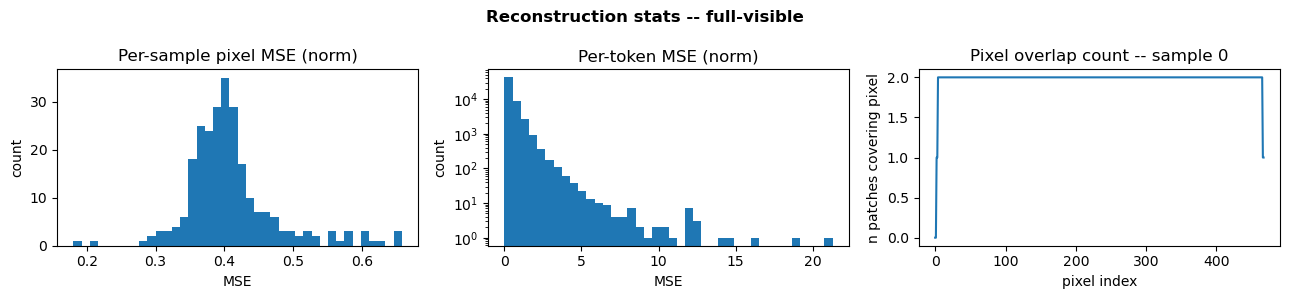

In [8]:
R_full = reconstruct(model, batch, masked=False)
print(f"recon_norm shape : {tuple(R_full['recon_norm'].shape)}")
print(f"N tokens         : {R_full['N']}  (P={R_full['P']}, S={R_full['S']}, L_used={R_full['L_used']})")
tok_mse_full = recon_summary(R_full, tag="full-visible")


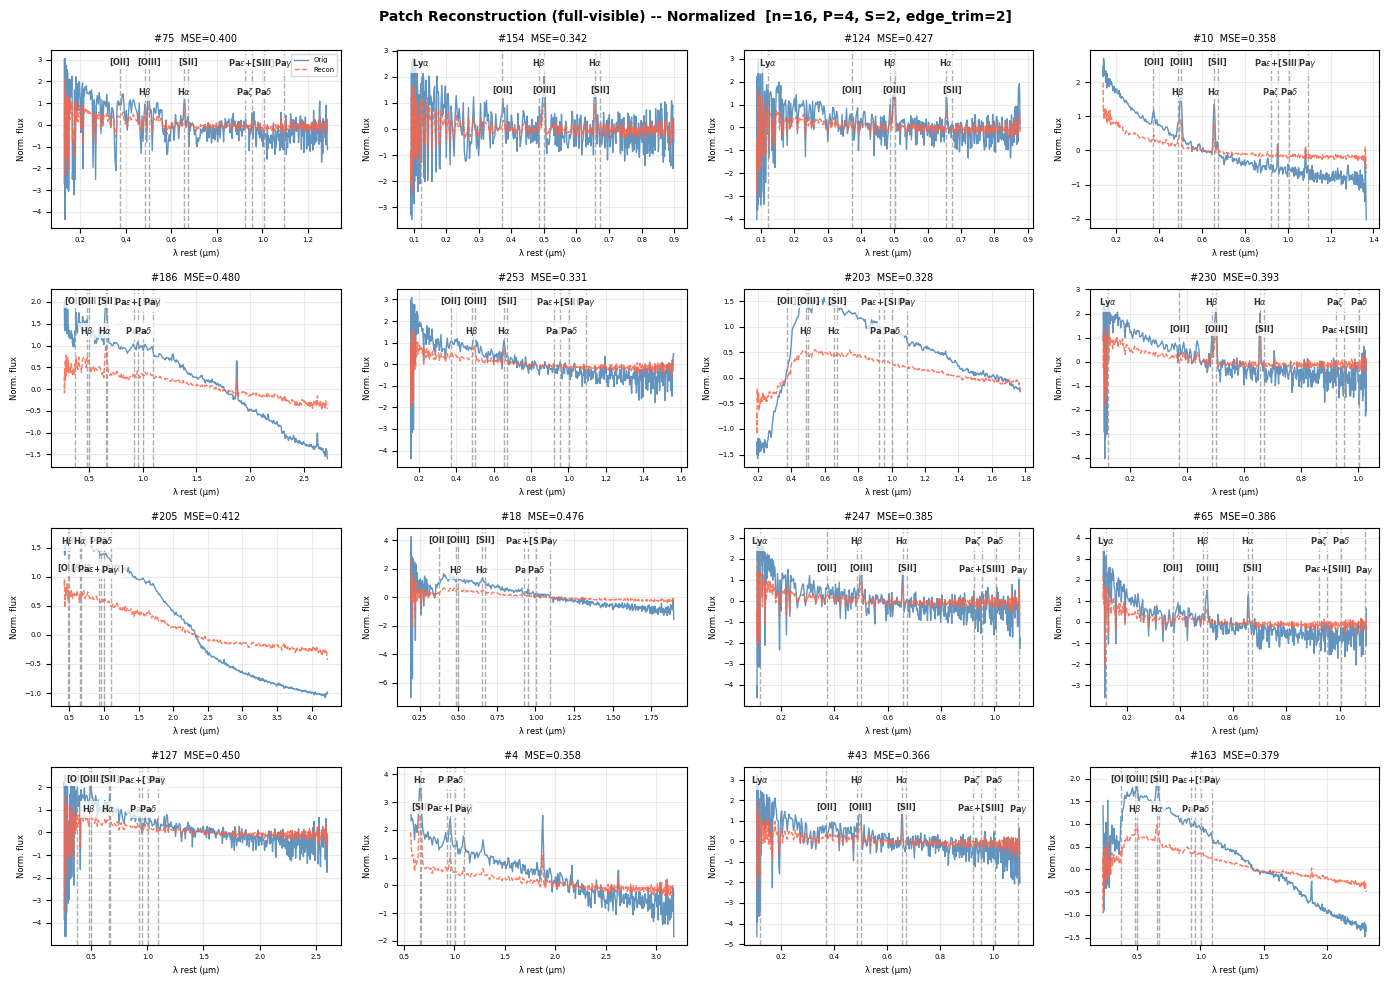

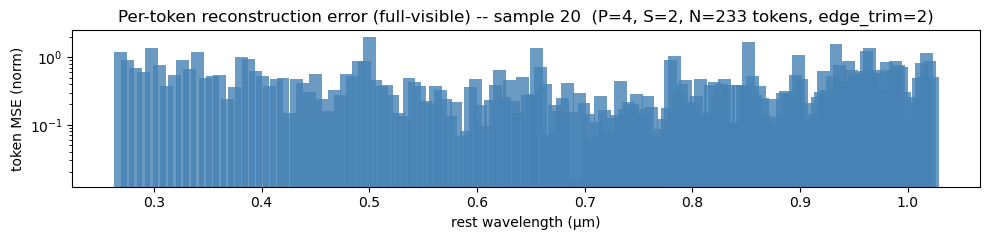

In [9]:
i_show = min(20, R_full['flux'].shape[0] - 1)
gallery(R_full, tag="full-visible", n_gallery=16)
per_token_bar(R_full, tok_mse_full, i=i_show, tag="full-visible")


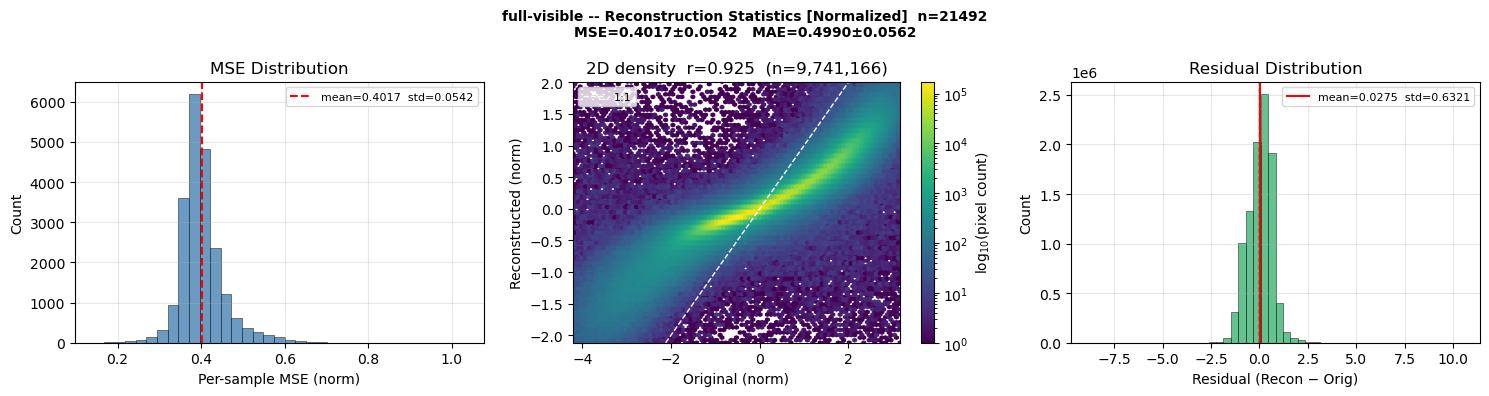

[full-visible]  Total valid pixels : 9,698,936  (edge_trim=2)
[full-visible]  Mean pixel MSE     : 0.3954  +-  0.8600


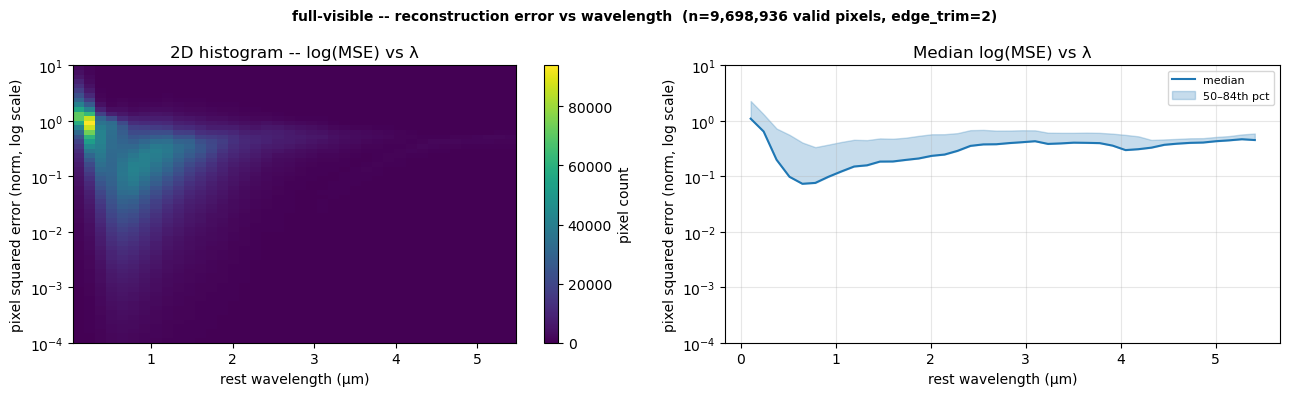

In [10]:
recon_vs_orig(recon_full, tag="full-visible")
mse_vs_wavelength(recon_full, tag="full-visible")


[full-visible]  Total pixels   : 9,698,936  (edge_trim=2)
[full-visible]  Outlier pixels : 9,014  (0.09%)  threshold = ±5.0σ  (σ=0.6283)


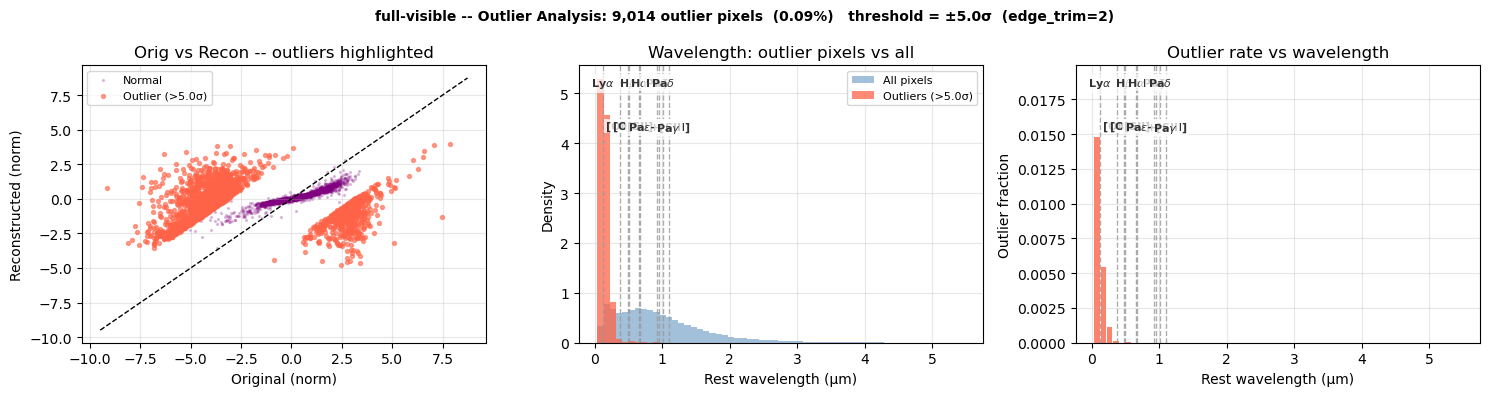

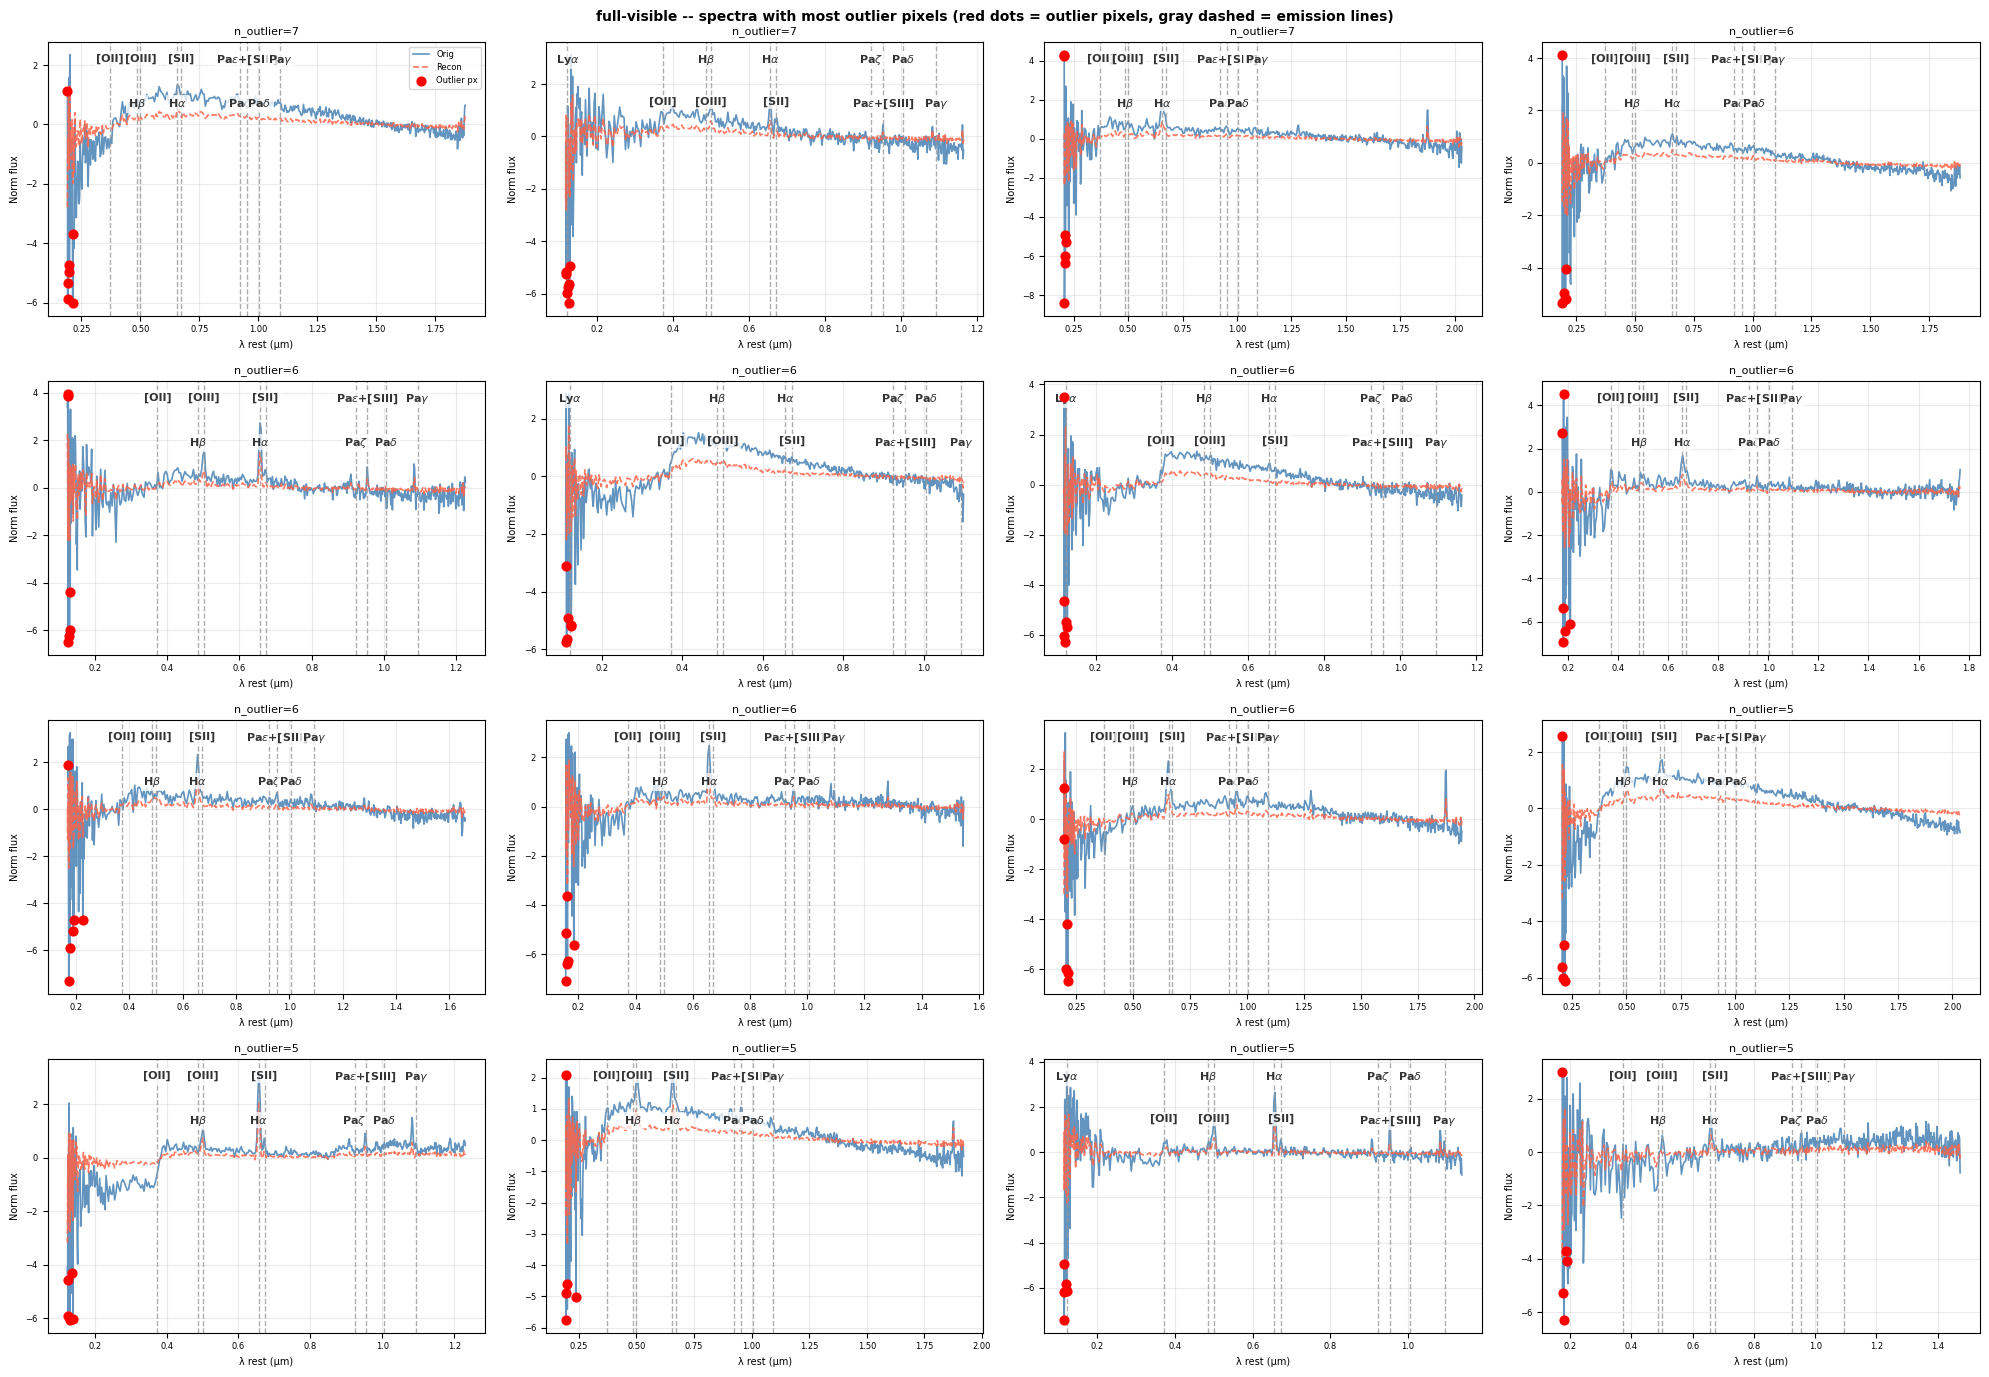

In [11]:
outlier_analysis(recon_full, tag="full-visible", n_gallery_out=16)


In [ ]:
# Residual map over (redshift, rest-frame wavelength). z-axis uses the catalogue
# z_best of the selected sample; emission lines appear as horizontal stripes.
residual_map(recon_full, dataset=ds, tag="full-visible", metric='rmse')
residual_map(recon_full, dataset=ds, tag="full-visible",
             outliers_only=True, outlier_nsigma=3.0, metric='mean')


[full-visible]  Selection : 21492/21492 objects  [no extra cut]
[full-visible]  Spectra : 21492   z range : [0.000, 14.480]   edge_trim=2


---
## Section B · Masked (MAE-consistent) reconstruction

For each token a leak-free `BLOCK_K`-token block centred on it is masked (whole
patch vectors zeroed, exactly as training masks) and the model predicts the
hidden token from context. This matches the training objective and is the
**trustworthy** reconstruction readout. Costs `N` forward passes per batch.

In [ ]:
R_mask = reconstruct(model, batch, masked=True, block_k=BLOCK_K)
print(f"BLOCK_K = {BLOCK_K}   (leak-free block for stride={STEP}, patch={PATCH_SIZE})")
print(f"recon_norm shape : {tuple(R_mask['recon_norm'].shape)}")
print(f"N tokens         : {R_mask['N']}  (P={R_mask['P']}, S={R_mask['S']}, L_used={R_mask['L_used']})")
print("note: masked readout runs N forward passes per batch -> slower than Section A")
tok_mse_mask = recon_summary(R_mask, tag=f"masked K={BLOCK_K}")


In [ ]:
i_show = min(20, R_mask['flux'].shape[0] - 1)
gallery(R_mask, tag=f"masked K={BLOCK_K}")
per_token_bar(R_mask, tok_mse_mask, i=i_show, tag=f"masked K={BLOCK_K}")


In [ ]:
recon_vs_orig(recon_mask, tag=f"masked K={BLOCK_K}")
mse_vs_wavelength(recon_mask, tag=f"masked K={BLOCK_K}")


In [ ]:
outlier_analysis(recon_mask, tag=f"masked K={BLOCK_K}")


In [ ]:
residual_map(recon_mask, dataset=ds, tag=f"masked K={BLOCK_K}", metric='rmse')
residual_map(recon_mask, dataset=ds, tag=f"masked K={BLOCK_K}",
             outliers_only=True, metric='mean')


---
## Dataset overview (EDA)

Redshift / grade / valid-token statistics for the aligned PRISM catalogue and the
selected reconstruction sample.

In [ ]:
# Dataset EDA from the aligned catalogue + tokeniser validity (no YAML needed).
N_total    = len(z_best)
N_sel      = int(SELECT.sum())
valid_frac = np.asarray(V).mean(axis=1)          # fraction of valid tokens / spectrum (full set)

fig, axes = plt.subplots(2, 2, figsize=(12, 8)); flat = axes.flatten()

ax = flat[0]
zf = z_best[np.isfinite(z_best)]
bins_z = np.linspace(np.nanmin(zf), np.nanmax(zf), 60)
ax.hist(zf,             bins=bins_z, color='steelblue', alpha=0.55, label=f'All PRISM ({N_total:,})')
ax.hist(z_best[SELECT], bins=bins_z, color='tomato',    alpha=0.80, label=f'Selected ({N_sel:,})')
ax.set_xlabel('z_best'); ax.set_ylabel('count'); ax.set_title('Redshift', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = flat[1]
gv, gc = np.unique(grade, return_counts=True)
ax.bar([str(int(g)) for g in gv], gc, color='steelblue', alpha=0.8)
ax.set_xlabel('grade'); ax.set_ylabel('count'); ax.set_title('Grade distribution', fontweight='bold')
ax.grid(alpha=0.3)

ax = flat[2]
ax.hist(valid_frac,         bins=40, color='steelblue', alpha=0.55, label='All')
ax.hist(valid_frac[SELECT], bins=40, color='tomato',    alpha=0.80, label='Selected')
ax.set_xlabel('valid-token fraction'); ax.set_ylabel('count')
ax.set_title('Valid-token fraction', fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = flat[3]; ax.axis('off')
rows = [
    ['N spectra',          f'{N_total:,}',                       f'{N_sel:,}'],
    ['z median',           f'{np.nanmedian(z_best):.3f}',        f'{np.nanmedian(z_best[SELECT]):.3f}'],
    ['valid-frac median',  f'{np.median(valid_frac):.3f}',       f'{np.median(valid_frac[SELECT]):.3f}'],
    ['tokens / spectrum',  f'{X.shape[1]}',                      f'{X.shape[1]}'],
    ['patch_dim (P+2)',    f'{PATCH_DIM}',                       f'{PATCH_DIM}'],
]
tbl = ax.table(cellText=rows, colLabels=['Metric', 'All PRISM', 'Selected'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.8)
ax.set_title('Summary', pad=12)

plt.suptitle('Dataset EDA -- PRISM, aligned catalogue '
             f'[grade==3 & z>=0 selected: {N_sel:,}/{N_total:,}]',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
